In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("loan_approval.csv")
print(df.shape)
df.head()

(3000, 7)


,age,income,credit_score,debt_ratio,num_loans,employed,approved
0,24,114096,688,0.757,0,0,0
1,55,63205,724,0.169,3,1,1
2,49,60412,843,0.161,0,0,1
3,40,95669,759,0.206,0,1,1
4,40,115122,558,0.335,2,0,1


In [3]:
print(df.shape, df['approved'].value_counts().to_dict())

(3000, 7) {1: 1866, 0: 1134}


In [4]:
# saperate features and target
X = df.drop(columns=["approved"])
y = df["approved"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y
)

Part A  
The basics: grow it, read it, judge it  
TASK 01  
Grow an unpruned tree and prove it overfits

In [7]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Tree complexity
print("Tree Depth:", tree.get_depth())
print("Number of Leaves:", tree.get_n_leaves())

# Accuracy Comparison
tr_acc = tree.score(X_train, y_train)
te_acc = tree.score(X_test, y_test)
print(f"\nTrain Accuracy: {tr_acc:3f}")
print(f"Test Accuracy: {te_acc:.3f}")

Tree Depth: 22
Number of Leaves: 432

Train Accuracy: 1.000000
Test Accuracy: 0.729


In [9]:
# Calculate Accuracy gap
acc_gap = tr_acc - te_acc
print(f"Accuracy Gap: {acc_gap:.3f}")

Accuracy Gap: 0.271


* The large gap between the near-perfect training accuracy and lower test accuracy shows overfitting because the tree has learned the training data too closely and does not generalize as well to unseen data.

TASK 02  
Sweep max_depth and find the sweet spot

In [10]:
depths = range(1, 16)
tr_acc, te_acc = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, min_samples_leaf=5, random_state=42)
    tree.fit(X_train, y_train)
    tr_acc.append(tree.score(X_train, y_train))
    te_acc.append(tree.score(X_test, y_test))

best_depth = depths[te_acc.index(max(te_acc))]

print("Best Depth:", best_depth)
print("Best Test Accuracy", max(te_acc))

Best Depth: 3
Best Test Accuracy 0.812


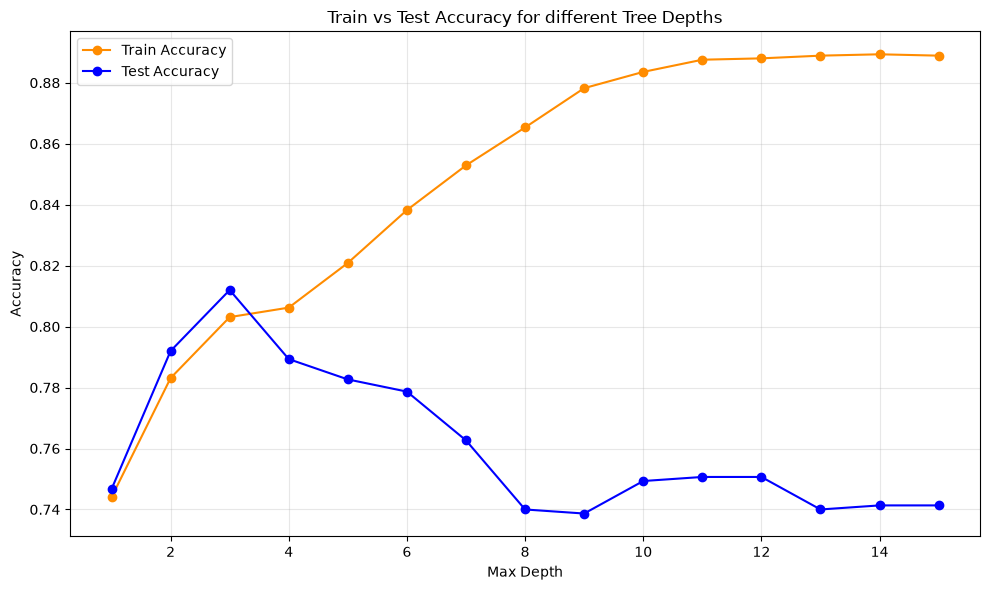

In [16]:
# plot train vs test accuracy
plt.figure(figsize=(10, 6))
plt.plot(depths, tr_acc, "o-", label="Train Accuracy", color="darkorange")
plt.plot(depths, te_acc, "o-", label="Test Accuracy", color="blue")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy for different Tree Depths")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Depth_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

Part B  
read the model back  
TASK 03   
Draw the tree and read it as rules

In [12]:
# Create the pruned/restricted Decision Tree
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
tree.fit(X_train, y_train)

print("Tree Depth:", tree.get_depth())
print("Number of Leaves:", tree.get_n_leaves())

Tree Depth: 4
Number of Leaves: 16


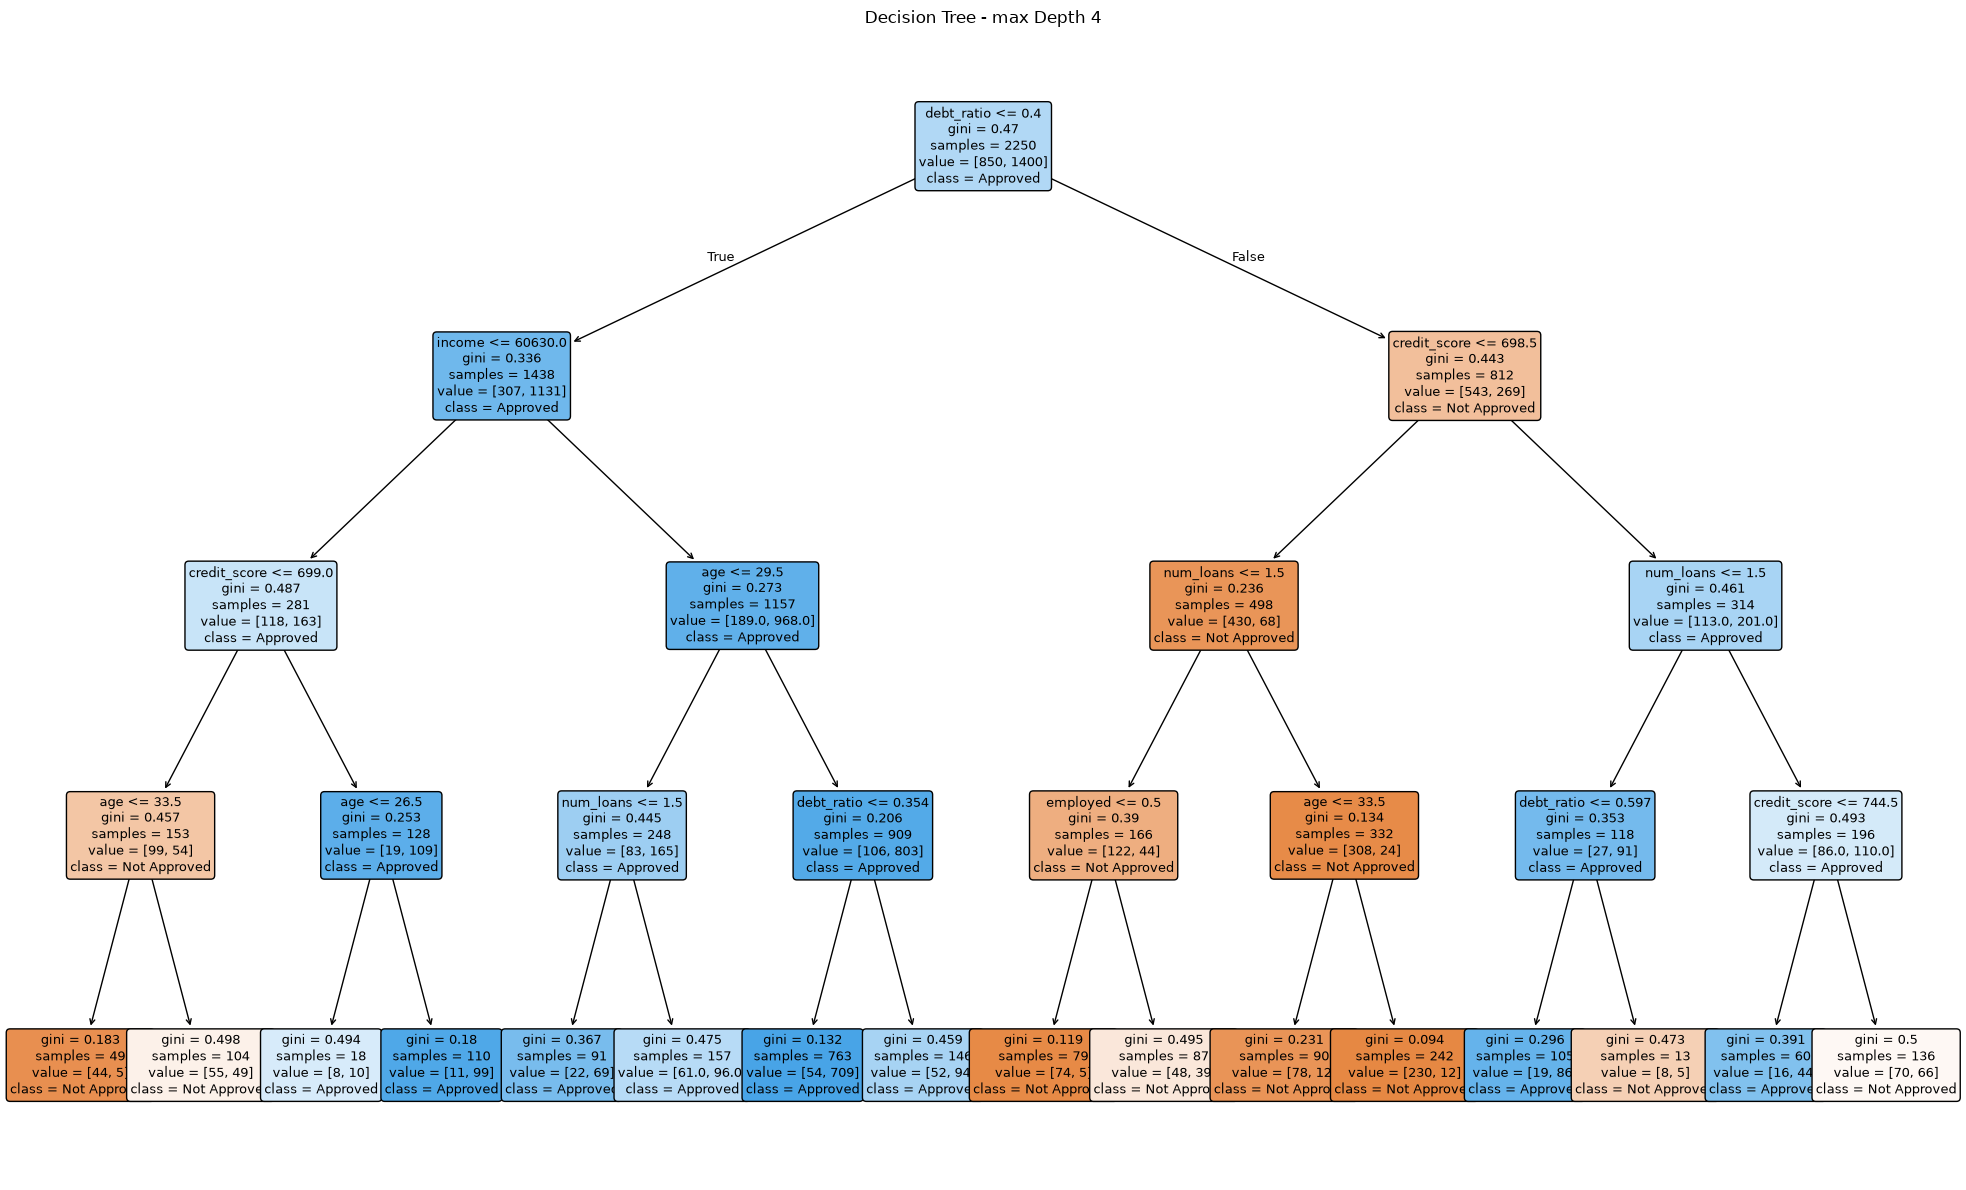

In [13]:
# Draw the decision tree
plt.figure(figsize=(20, 12))
plot_tree(
    tree, 
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - max Depth 4")
plt.tight_layout()
plt.savefig("Decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

* Rule 1 -->  
If the debt ratio is 0.4 or less, and income is ₹60,630 or less, and the credit score is 699 or less, and age is 33.5 or less, then the loan is likely to be Not Approved.

* Rule 2 -->  
If the debt ratio is 0.4 or less, income is ₹60,630 or less, the credit score is above 699, and age is 26.5 or less, then the loan is likely to be Approved.

* Rule 3 -->  
If the debt ratio is greater than 0.4, the credit score is 698.5 or less, the number of loans is 1.5 or less, and the applicant is employed, then the loan is likely to be Not Approved.

TASK 04  
Rank the features with feature_importance_

In [18]:
importances = pd.Series(
    tree.feature_importances_, index=X.columns
).sort_values(ascending=True)

print("Feature Importance:")
print(importances)

Feature Importance:
employed        0.026207
num_loans       0.036730
income          0.063564
age             0.068752
credit_score    0.293504
debt_ratio      0.511243
dtype: float64


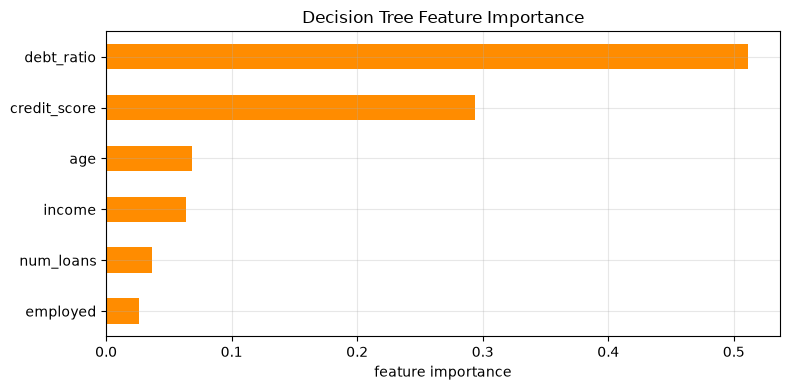

In [19]:
# Plot sorted feature importance
importances.plot(kind="barh", color="darkorange", figsize=(8, 4))
plt.xlabel("feature importance")
plt.title("Decision Tree Feature Importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Que.  Which feature drives approval most and why the others matter less.  
Ans.  Debt ratio is the most important feature for predicting loan approval, followed by credit score. The other features have lower importance because they contribute less to reducing uncertainty in the decision tree.

Sanity-check: do the two top features match the salience you saw at the root of the tree?  

Yes. The two top features match the tree's salience: debt_ratio is the root split, while credit_score appears immediately in the next major splits.

Part C  
regularize and compare scientifically  
TASK 05  
Use cross-validation and a single pipeline to tune honestly

In [21]:
from sklearn.pipeline import Pipeline

# Create the decision tree pipeline
pipe = Pipeline([
    ("tree", DecisionTreeClassifier(
        min_samples_leaf=5, random_state=42
    ))
])

print(pipe)

Pipeline(steps=[('tree',
                 DecisionTreeClassifier(min_samples_leaf=5, random_state=42))])


In [25]:
# Test max_depth values from 1 to 15
scores = {}
for d in range(1, 16):
    pipe.set_params(tree__max_depth=d)

    cv_score = cross_val_score(
        pipe, X_train, y_train, cv=5, scoring="accuracy"
    ).mean()

    scores[d] = cv_score

print("CV Results:")
for depth, score in scores.items():
    print(f"Depth: {depth}, CV Accuracy: {score:.3f}")

CV Results:
Depth: 1, CV Accuracy: 0.732
Depth: 2, CV Accuracy: 0.775
Depth: 3, CV Accuracy: 0.790
Depth: 4, CV Accuracy: 0.784
Depth: 5, CV Accuracy: 0.780
Depth: 6, CV Accuracy: 0.782
Depth: 7, CV Accuracy: 0.781
Depth: 8, CV Accuracy: 0.777
Depth: 9, CV Accuracy: 0.771
Depth: 10, CV Accuracy: 0.768
Depth: 11, CV Accuracy: 0.768
Depth: 12, CV Accuracy: 0.766
Depth: 13, CV Accuracy: 0.764
Depth: 14, CV Accuracy: 0.764
Depth: 15, CV Accuracy: 0.758


In [26]:
# Find depth with the highest cv mean
best_d = max(scores, key=scores.get)
print("Best Depth by CV:", best_d)
print(f"Best CV mean accuracy: {scores[best_d]:.3f}")

Best Depth by CV: 3
Best CV mean accuracy: 0.790


In [30]:
# Compare with Task02
print("Comparison with Task 02")
print("-" * 25)

print("Best depth from Single Split:", best_depth)
print(f"Best Test accuracy from single split: {max(te_acc):.3f}")
print("Best depth by CV:", best_d)
print(f"Best CV mean accuracy: {scores[best_d]:.3f}")

Comparison with Task 02
-------------------------
Best depth from Single Split: 3
Best Test accuracy from single split: 0.812
Best depth by CV: 3
Best CV mean accuracy: 0.790


In [33]:
# Fit the CV-Selected model on the full training set
pipe.set_params(tree__max_depth=best_d)
pipe.fit(X_train, y_train)

final_te_acc = pipe.score(X_test, y_test)

print("Final Evaluation:")
print("-" * 18)
print("CV selected Depth:", best_d)
print("Held-out Test Accuracy:", round(final_te_acc, 3))

Final Evaluation:
------------------
CV selected Depth: 3
Held-out Test Accuracy: 0.812


* The CV mean can differ from the earlier single-split accuracy because cross-validation evaluates the model on multiple validation folds instead of relying on one particular train/test split. Therefore, the CV score gives a more stable estimate of how well the tree generalizes.

TASK 06  
Tree vs linear model: does the tree earn its place?

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

# Logistic Regression Pipeline
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000, random_state=42
    ))
])

print(log_pipe)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [35]:
# Pruned Tree pipeline
tree_pipe = Pipeline([
    ("tree", DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=5,
        random_state=42
    ))
])

print(tree_pipe)

Pipeline(steps=[('tree',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,
                                        random_state=42))])


In [40]:
# Cross validation accuracy
log_acc = cross_val_score(
    log_pipe, X_train, y_train,
    cv=5, scoring='accuracy'
).mean()

tree_acc = cross_val_score(
    tree_pipe, X_train, y_train,
    cv=5, scoring='accuracy'
).mean()

print("CV Comparison")
print("-" * 14)
print(f"Logistic Regression CV Accuracy: {log_acc:.3f}")
print(f"Decision Tree CV Accuracy: {tree_acc:.3f}")

CV Comparison
--------------
Logistic Regression CV Accuracy: 0.740
Decision Tree CV Accuracy: 0.784


In [44]:
# Cross Validation ROC-AUC
log_auc = cross_val_score(
    log_pipe, X_train, y_train,
    cv=5, scoring="roc_auc"
).mean()

tree_auc = cross_val_score(
    tree_pipe, X_train, y_train,
    cv=5, scoring="roc_auc"
).mean()

print("CV ROC-AUC Comparison")
print("-" * 22)
print(f"Logistic Regression CV ROC-AUC: {log_auc:.3f}")
print(f"Decision Tree CV ROC-AUC: {tree_auc:.3f}")

CV ROC-AUC Comparison
----------------------
Logistic Regression CV ROC-AUC: 0.780
Decision Tree CV ROC-AUC: 0.844


In [45]:
# Determine which model performs better
if tree_acc > log_acc:
    print("The Decision Tree has higher CV accuracy than Logistic Regression.")
else:
    print("The Logistic Regression has higher CV accuracy than decision tree")


if tree_auc > log_auc:
    print("The Decision Tree also has higher ROC-AUC")
else:
    print("The Logistic Regression also has higher ROC-AUC")

The Decision Tree has higher CV accuracy than Logistic Regression.
The Decision Tree also has higher ROC-AUC


* The Decision Tree beats Logistic Regression on this nonlinear dataset because it can capture nonlinear relationships and feature interactions that a linear model cannot. The trade-off is that the tree is more complex and less interpretable as one simple linear relationship, although pruning helps control its complexity.